In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans , DBSCAN , AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
rfm = pd.read_csv("../data/processed/rfm_data.csv")
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue
0,12346.0,165,2,163.41,81.705
1,12347.0,3,2,1323.32,661.660
2,12348.0,74,1,221.16,221.160
3,12349.0,43,2,2221.14,1110.570
4,12351.0,11,1,300.93,300.930


In [3]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4285 entries, 0 to 4284
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     4285 non-null   float64
 1   Recency        4285 non-null   int64  
 2   Frequency      4285 non-null   int64  
 3   Monetary       4285 non-null   float64
 4   AvgOrderValue  4285 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 167.5 KB


In [4]:
X = rfm.drop("CustomerID", axis=1)

### Apply Log transformation for Monetary & AvgOrderValue

In [5]:
rfm_log = X.copy()
rfm_log["Monetary_log"] = np.log1p(rfm_log["Monetary"])
rfm_log["AvgOrderValue_log"] = np.log1p(rfm_log["AvgOrderValue"])

In [6]:
rfm_log

,Recency,Frequency,Monetary,AvgOrderValue,Monetary_log,AvgOrderValue_log
0,165,2,163.41,81.705000,5.102363,4.415280
1,3,2,1323.32,661.660000,7.188654,6.496262
2,74,1,221.16,221.160000,5.403398,5.403398
3,43,2,2221.14,1110.570000,7.706226,7.013529
4,11,1,300.93,300.930000,5.710195,5.710195
...,...,...,...,...,...,...
4280,18,6,641.77,106.961667,6.465787,4.681776
4281,67,1,411.68,411.680000,6.022672,6.022672
4282,296,1,377.00,377.000000,5.934894,5.934894
4283,112,2,1246.43,623.215000,7.128841,6.436495


In [7]:
rfm_log.drop(["Monetary", "AvgOrderValue"], axis=1, inplace=True)

In [39]:
rfm_log.to_csv("../data/processed/rfm_log.csv", index=False)

In [8]:
inertia = []
K = range(2, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_log)
    inertia.append(kmeans.inertia_)

### Make Elbow method for chooce the best k

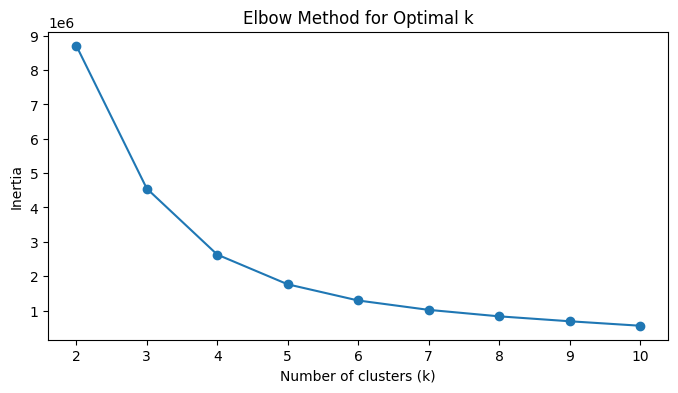

In [9]:
plt.figure(figsize=(8,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [10]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_log)
    score = silhouette_score(rfm_log, labels)
    print(f"k={k} → Silhouette Score: {score:.3f}")

k=2 → Silhouette Score: 0.731
k=3 → Silhouette Score: 0.653
k=4 → Silhouette Score: 0.582
k=5 → Silhouette Score: 0.573
k=6 → Silhouette Score: 0.558


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_log)

In [12]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Cluster
0,12346.0,165,2,163.41,81.705,2
1,12347.0,3,2,1323.32,661.660,0
2,12348.0,74,1,221.16,221.160,3
3,12349.0,43,2,2221.14,1110.570,0
4,12351.0,11,1,300.93,300.930,0


### Show if clusters are well separated using PCA

<Axes: >

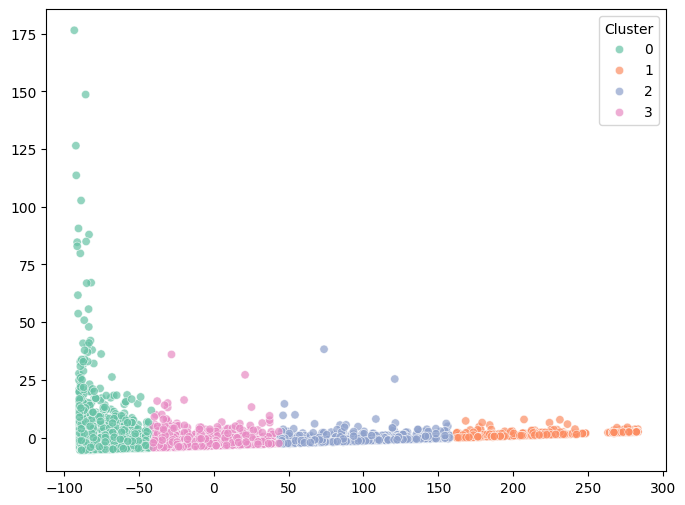

In [15]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(rfm_log)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=rfm["Cluster"],
    palette="Set2",
    alpha=0.7
)

### Cluster Profiling

In [16]:
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "AvgOrderValue": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "NumCustomers"})

cluster_profile

,Recency,Frequency,Monetary,AvgOrderValue,NumCustomers
Cluster,,,,,
0,20.103515,6.531054,3167.009523,386.280206,2077
1,306.943311,1.360544,504.676395,325.030982,441
2,189.921753,2.079812,731.269937,335.777293,639
3,79.363475,3.078014,1208.148954,393.679397,1128


## DBSCAN

<module 'matplotlib.pyplot' from 'c:\\Users\\DELL\\Desktop\\ML Projects\\Customer_Segmentation\\customer\\Lib\\site-packages\\matplotlib\\pyplot.py'>

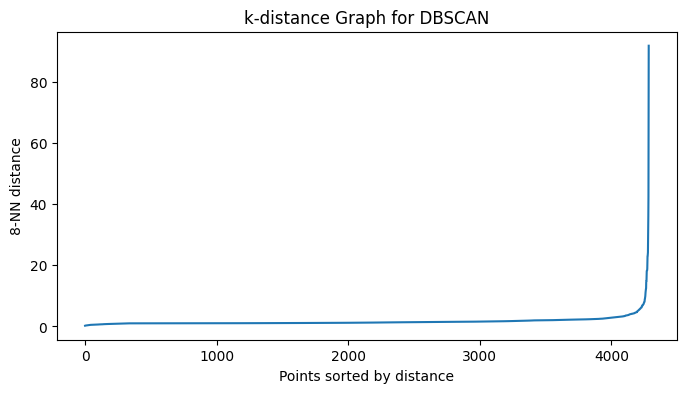

In [17]:
from sklearn.neighbors import NearestNeighbors
min_samples = 8 
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(rfm_log)
distances, indices = neighbors_fit.kneighbors(rfm_log)

distances = np.sort(distances[:, min_samples - 1])
plt.figure(figsize=(8,4))
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("k-distance Graph for DBSCAN")
plt

In [18]:
dbscan = DBSCAN(
    eps=2.0,
    min_samples=min_samples
)
rfm["DBSCAN_Cluster"] = dbscan.fit_predict(rfm_log)

In [70]:
rfm["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
-1     410
 6     347
 4     339
 1     318
 13    258
 7     251
 3     168
 12    167
 15    158
 10    155
 21    149
 2     126
 14     93
 19     73
 20     71
 27     54
 40     53
 8      52
 0      50
 22     50
 32     49
 25     45
 30     41
 11     41
 42     41
 31     41
 16     40
 28     38
 39     38
 38     37
 44     36
 33     34
 17     33
 26     30
 29     30
 5      29
 47     29
 49     27
 41     25
 9      24
 24     24
 36     22
 37     22
 18     20
 50     19
 34     18
 45     17
 35     16
 23     13
 43     13
 51     11
 48     10
 46      9
 52      8
 54      8
 53      5
Name: count, dtype: int64

### DBSCAN good for Noise & Outlier

In [71]:
dbscan_profile = rfm.groupby("DBSCAN_Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "AvgOrderValue": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "NumCustomers"})

dbscan_profile

,Recency,Frequency,Monetary,AvgOrderValue,NumCustomers
DBSCAN_Cluster,,,,,
-1,105.158537,15.387805,9903.675512,683.277035,410
0,163.800000,2.060000,641.013600,341.387520,50
1,2.883648,6.751572,2397.827327,341.893933,318
2,72.301587,2.611111,976.981984,366.778040,126
3,44.636905,2.470238,907.729405,341.675649,168
4,9.634218,5.129794,1834.809735,340.381048,339
5,205.137931,1.517241,461.320345,328.032989,29
6,16.360231,4.296830,1605.055677,353.382484,347
7,30.402390,3.745020,1331.448725,361.586400,251


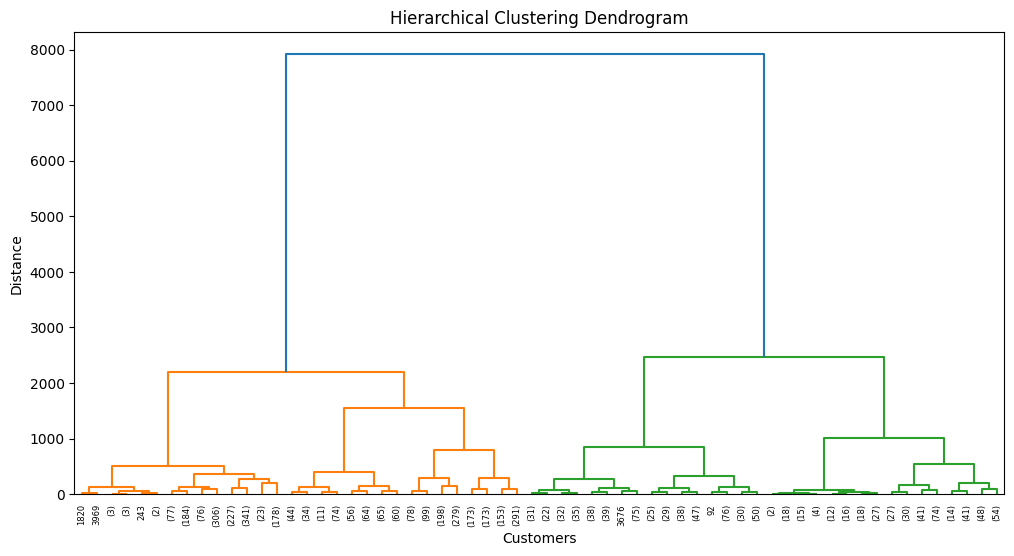

In [19]:
linked = linkage(rfm_log, method="ward")
plt.figure(figsize=(12,6))
dendrogram(
    linked,
    truncate_mode="level",
    p=5
)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

## Hierarchical

In [20]:
hc = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)
rfm["Hierarchical_Cluster"] = hc.fit_predict(rfm_log)

In [21]:
hc_profile = rfm.groupby("Hierarchical_Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "AvgOrderValue": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "NumCustomers"})

hc_profile

,Recency,Frequency,Monetary,AvgOrderValue,NumCustomers
Hierarchical_Cluster,,,,,
0,66.712203,3.291577,1308.475999,389.767245,1852
1,306.943311,1.360544,504.676395,325.030982,441
2,196.142355,1.998243,711.422671,338.476667,569
3,12.284610,7.823612,3921.191314,384.043483,1423


In [22]:
sil_score = silhouette_score(rfm_log, rfm["Hierarchical_Cluster"])
print(f"Silhouette Score (Hierarchical, k=4): {sil_score:.3f}")

Silhouette Score (Hierarchical, k=4): 0.480
